<a href="https://colab.research.google.com/github/Michael2004-ukpeh/ml-playground/blob/master/Multivariable_Linear_Reg_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

# Import Dataset from Kaggle

In [ ]:
import kagglehub
# Download latest version
path = kagglehub.dataset_download("hussainnasirkhan/multiple-linear-regression-dataset")

print("Path to dataset files:", path)
# List the contents of the directory
display(os.listdir(path))


Using Colab cache for faster access to the 'multiple-linear-regression-dataset' dataset.
Path to dataset files: /kaggle/input/multiple-linear-regression-dataset


['multiple_linear_regression_dataset.csv']

# Read dataset with pandas


In [ ]:
df = pd.read_csv(os.path.join(path, 'multiple_linear_regression_dataset.csv'))
df

,age,experience,income
0,25,1,30450
1,30,3,35670
2,47,2,31580
3,32,5,40130
4,43,10,47830
5,51,7,41630
6,28,5,41340
7,33,4,37650
8,37,5,40250
9,39,8,45150


# Normalize independent variables of age, X1 and income, X2

For normalization, I'll use Min-Max scaling. This method rescales the feature linearly to a given range, usually between zero and one. The formula for Min-Max scaling is: `X_norm = (X - X_min) / (X_max - X_min)`

In [ ]:
# Extract ages from values
ages = df['age'].values

# Min-Max Normalize 'age' (X1)
ages_min = np.min(ages)
ages_max = np.max(ages)

X1 = (ages - ages_min) / (ages_max - ages_min)

print("Normalized Age (X1):")
display(X1)
X1.shape[0]

Normalized Age (X1):


array([0.05714286, 0.2       , 0.68571429, 0.25714286, 0.57142857,
       0.8       , 0.14285714, 0.28571429, 0.4       , 0.45714286,
       0.17142857, 0.68571429, 0.88571429, 0.8       , 0.6       ,
       0.51428571, 1.        , 0.        , 0.6       , 0.4       ])

20

In [ ]:
# Extract 'experience' as X2
exprs = df['experience'].values

# Min-Max Normalize 'experince' (X2)
exprs_min = np.min(exprs)
exprs_max = np.max(exprs)
X2 = (exprs - exprs_min) / (exprs_max - exprs_min)

print("\nNormalized Experience (X2):")
display(X2)
X2.shape[0]


Normalized Experience (X2):


array([0.    , 0.125 , 0.0625, 0.25  , 0.5625, 0.375 , 0.25  , 0.1875,
       0.25  , 0.4375, 0.    , 0.5   , 0.25  , 0.1875, 0.6875, 0.3125,
       1.    , 0.    , 0.5   , 0.5625])

20

# Extract dependent variable, Y
Extract income and normalize to Y

In [ ]:
incomes  = df['income'].values
#  Normalize income
incomes_min = np.min(incomes)
incomes_max = np.max(incomes)
Y = (incomes - incomes_min) / (incomes_max - incomes_min)

print("\nNormalized Income (Y):")
display(Y)
Y.shape[0]


Normalized Income (Y):


array([0.07298658, 0.21895973, 0.10458613, 0.34368009, 0.55900447,
       0.3856264 , 0.37751678, 0.27432886, 0.34703579, 0.4840604 ,
       0.        , 0.51090604, 0.24832215, 0.19463087, 0.65604027,
       0.30928412, 1.        , 0.08473154, 0.45721477, 0.58333333])

20

# Training

## Training functions

In [ ]:
# Prediction
def pred(X1, X2, m1, m2,  c):
  return m1 * X1+ m2 * X2 + c

In [ ]:
# Cost function or mean squared function
def cost_function( Y, Y_pred):
  return np.mean((Y -  Y_pred)**2)

In [ ]:
# Calculate gradient descent
def gradient_change(X1,X2, Y, m1,m2,  c):
  """
  X1 is the independent variable
  X2 is the independent variable
  Y is the dependent variable
  m1 is the current value of m1
  m2 is the current value of m2
  c is the current value of c
  """
  n = X1.shape[0]
  Y_pred = pred(X1, X2,  m1, m2, c)
  # Calculate error ( Pred minus original)
  error = Y - Y_pred
  # Calculate gradients
  dm1 = (-2.0/n) * np.sum(error * X1)
  dm2 = (-2.0/n) * np.sum(error * X2)
  dc = (-2.0/n) * np.sum(error)
  return dm1, dm2, dc


## Training
1.   Calculate prediction
2.   Compute error
3.   Calculate the gradients w.r.t m and c to help fit the data
4.  Update m and c iteratively in every epoch to reduce error to its minimum value

In [ ]:
def train( X1, X2, Y, m1,m2, c, alpha, epochs, m1_arr,m2_arr,  c_arr, err_arr):
  for i in range(epochs):
    # Compute current loss function
    Y_pred = pred(X1,X2, m1, m2, c)
    err = cost_function(Y, Y_pred)
    dm1, dm2, dc = gradient_change(X1,X2,Y, m1,m2, c)

    # Track errors , m and c
    m1_arr.append(m1)
    m2_arr.append(m2)
    c_arr.append(c)
    err_arr.append(err)

    # Adjust parameters
    m1  -= alpha * dm1
    m2  -= alpha * dm2
    c  -=  alpha * dc

    print(f"Epoch {i}: MSE = {err}\n")
  print(f"Final parameters -  m1:{m1}| m2:{m2} | c:{c}")
  return m1, m2,  c, m1_arr, m2_arr,  c_arr, err_arr


Train model with initial values of m1, m2 and c

In [ ]:
m1 = 0
m2 = 0
c = 0
alpha = 0.1
m1_arr = []
m2_arr = []
c_arr = []
err_arr = []
epochs = 10000
m1,m2, c, m1_arr,m2_arr, c_arr, err_arr = train(X1,X2, Y, m1,m2, c, alpha, epochs, m1_arr,m2_arr, c_arr, err_arr)

Streaming output truncated to the last 5000 lines.

Epoch 7501: MSE = 0.0011992968743854912

Epoch 7502: MSE = 0.0011992968743854912

Epoch 7503: MSE = 0.0011992968743854912

Epoch 7504: MSE = 0.0011992968743854912

Epoch 7505: MSE = 0.0011992968743854912

Epoch 7506: MSE = 0.0011992968743854912

Epoch 7507: MSE = 0.0011992968743854912

Epoch 7508: MSE = 0.0011992968743854912

Epoch 7509: MSE = 0.0011992968743854912

Epoch 7510: MSE = 0.0011992968743854912

Epoch 7511: MSE = 0.0011992968743854912

Epoch 7512: MSE = 0.0011992968743854912

Epoch 7513: MSE = 0.0011992968743854912

Epoch 7514: MSE = 0.0011992968743854912

Epoch 7515: MSE = 0.0011992968743854912

Epoch 7516: MSE = 0.0011992968743854912

Epoch 7517: MSE = 0.0011992968743854912

Epoch 7518: MSE = 0.0011992968743854912

Epoch 7519: MSE = 0.0011992968743854912

Epoch 7520: MSE = 0.0011992968743854912

Epoch 7521: MSE = 0.0011992968743854912

Epoch 7522: MSE = 0.0011992968743854912

Epoch 7523: MSE = 0.0011992968743854912

Epoch

# Plot Cost Function against number of epochs

/tmp/ipykernel_5711/94330842.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


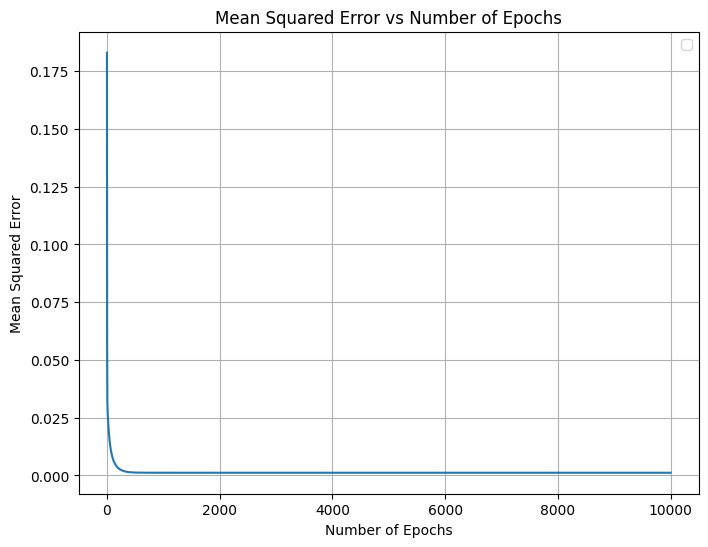

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(range(1,epochs + 1 ),err_arr)

plt.xlabel("Number of Epochs")
plt.ylabel("Mean Squared Error")
plt.title("Mean Squared Error vs Number of Epochs")
plt.grid(True)
plt.legend()

plt.show()

 # Plot Values of X1, X2 and Y with line of best fit

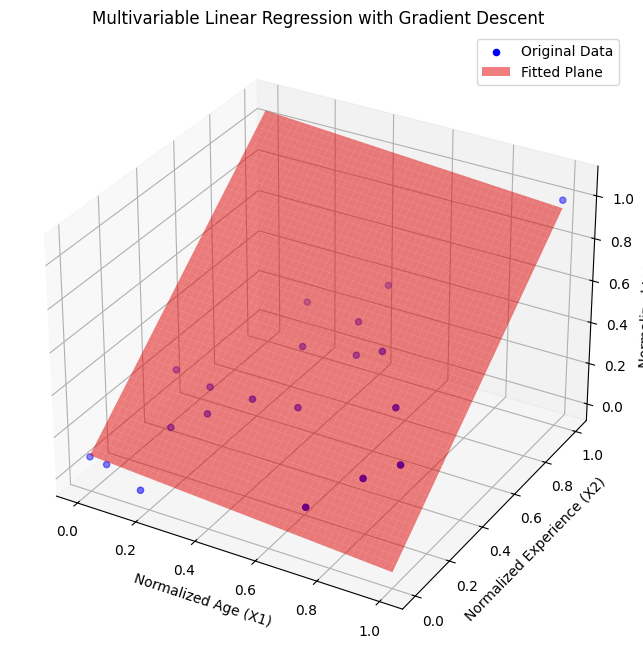

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot of the original data points
ax.scatter(X1, X2, Y, color='blue', label='Original Data')

# Create a meshgrid for X1 and X2 to plot the fitted plane
x1_surf = np.linspace(X1.min(), X1.max(), 100)
x2_surf = np.linspace(X2.min(), X2.max(), 100)
x1_surf, x2_surf = np.meshgrid(x1_surf, x2_surf)
y_surf = pred(x1_surf, x2_surf, m1, m2, c)

# Plot the fitted plane as a surface
ax.plot_surface(x1_surf, x2_surf, y_surf, color='red', alpha=0.5, label='Fitted Plane')

ax.set_xlabel('Normalized Age (X1)')
ax.set_ylabel('Normalized Experience (X2)')
ax.set_zlabel('Normalized Income (Y)')
ax.set_title('Multivariable Linear Regression with Gradient Descent')
ax.legend()
plt.show()